# DBSCAN — Density-Based Clustering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/dbscan/notes.ipynb)

*Teaching a clustering algorithm to say "I don't know."*

**The brief:** same Veloura fashion & lifestyle retailer as [GMM](../gaussian-mixture-models/notes.ipynb). Last
session's GMM gave Marketing soft, probabilistic segments — a real upgrade over hard clustering. Two new problems
just showed up, and GMM has no answer for either one.


## 1. Where GMM breaks

**Problem 1 — the forced-fit problem.** A handful of Veloura accounts have near-zero spend but a huge order
count — classic reseller or fraud-bot behavior. GMM scores every point against every Gaussian and always assigns
the highest-likelihood one, even when that likelihood is low for *every single Gaussian*. GMM has no concept of
"doesn't belong anywhere" — everyone gets a segment, resellers included.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors

rng = np.random.RandomState(7)
segment_means = [[160, 8, 12, 10], [45, 22, 4, 20], [70, 5, 45, 5]]
segment_covs = [
    [[400, 20, -30, 15], [20, 4, -2, 3], [-30, -2, 30, -2], [15, 3, -2, 4]],
    [[150, 25, -10, 20], [25, 9, -3, 6], [-10, -3, 20, -2], [20, 6, -2, 8]],
    [[250, -5, 40, -3], [-5, 2, -5, 1], [40, -5, 80, -3], [-3, 1, -3, 2]],
]
segment_sizes = [180, 210, 210]
feature_names = ["avg_order_value", "visit_frequency", "days_since_purchase", "orders"]

X_customers = np.vstack([rng.multivariate_normal(m, c, s) for m, c, s in zip(segment_means, segment_covs, segment_sizes)])
X_customers = np.clip(X_customers, 0, None)

# A handful of resellers/fraud accounts — near-zero spend, absurdly high order count. Not a real segment, just noise.
resellers = np.column_stack([
    rng.uniform(2, 10, 12),
    rng.uniform(60, 90, 12),
    rng.uniform(1, 3, 12),
    rng.uniform(80, 120, 12),
])
X_all = np.vstack([X_customers, resellers])
is_reseller = np.array([False] * len(X_customers) + [True] * len(resellers))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

gmm = GaussianMixture(n_components=3, covariance_type="full", n_init=5, random_state=7).fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

print("Reseller accounts and the segment GMM confidently forces them into:")
for i in np.where(is_reseller)[0][:4]:
    print(f"  Account #{i}: GMM segment {gmm_labels[i]}, confidence {gmm_probs[i].max():.2f}")

Reseller accounts and the segment GMM confidently forces them into:
  Account #600: GMM segment 2, confidence 1.00
  Account #601: GMM segment 2, confidence 1.00
  Account #602: GMM segment 2, confidence 1.00
  Account #603: GMM segment 2, confidence 1.00


GMM doesn't hesitate — it hands out a segment and a confidence score for accounts that clearly don't belong to
any of the three real customer types. A method that can say "this one doesn't fit anywhere" would be far more
useful here than one that's forced to pick its least-bad option.

**Problem 2 — the shape problem.** GMM assumes every segment is elliptical (a Gaussian shape). Some real Veloura
behavior patterns — think two different browsing styles that curve through feature space — aren't blobs at all.


In [2]:
X_moons, _ = make_moons(n_samples=500, noise=0.06, random_state=7)
gmm_moons = GaussianMixture(n_components=2, covariance_type="full", n_init=5, random_state=7).fit(X_moons)
gmm_moon_labels = gmm_moons.predict(X_moons)

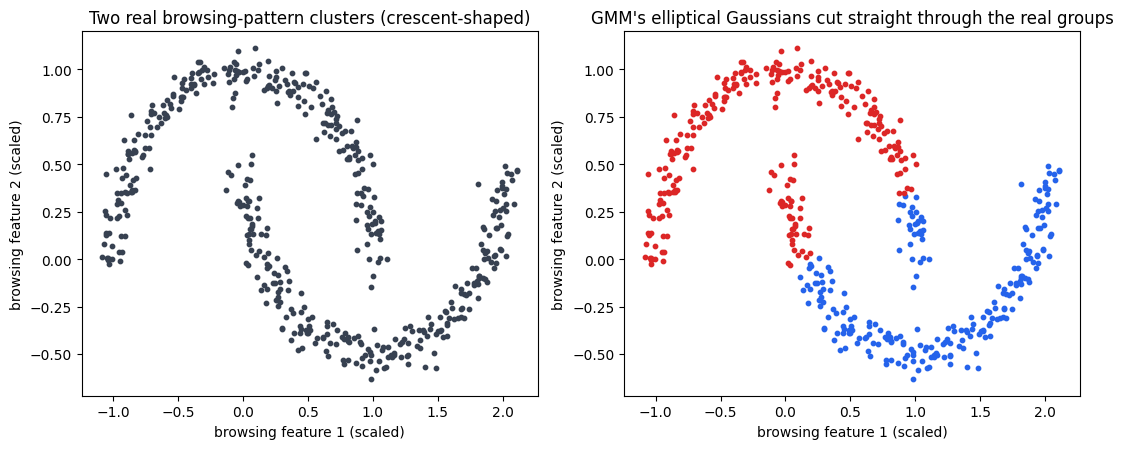

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], s=10, color="#374151")
axes[0].set_title("Two real browsing-pattern clusters (crescent-shaped)")

colors2 = ["#2563EB", "#DC2626"]
for j in range(2):
    axes[1].scatter(X_moons[gmm_moon_labels == j, 0], X_moons[gmm_moon_labels == j, 1], s=10, color=colors2[j])
axes[1].set_title("GMM's elliptical Gaussians cut straight through the real groups")
for ax in axes:
    ax.set_xlabel("browsing feature 1 (scaled)"); ax.set_ylabel("browsing feature 2 (scaled)")
plt.tight_layout()
plt.show()

GMM (and K-Means, and Hierarchical Clustering with most linkages) all assume clusters look roughly like blobs.
When the real structure curves, every one of those methods cuts through it in the wrong place.

**Quick check**

> A handful of Veloura accounts have near-zero spend and a huge order count. Under GMM, what happens to them?
>
> **They get forced into whichever segment has the highest (even if still very low) likelihood, with a
> confidence score attached.** GMM has no built-in way to say "none of these segments fit."


## 2. The core idea: clustering by density

GMM asks: *"which distribution best explains this point?"* K-Means asks: *"which centroid is this point
closest to?"* Both questions force an answer for every point.

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise) asks a different question: "is this
point sitting in a crowded neighborhood, or an empty one?"** A cluster is just a region where points are packed
densely together. A point sitting off on its own, with no dense neighborhood nearby, is allowed to just be
*noise* — not a forced member of the nearest cluster.


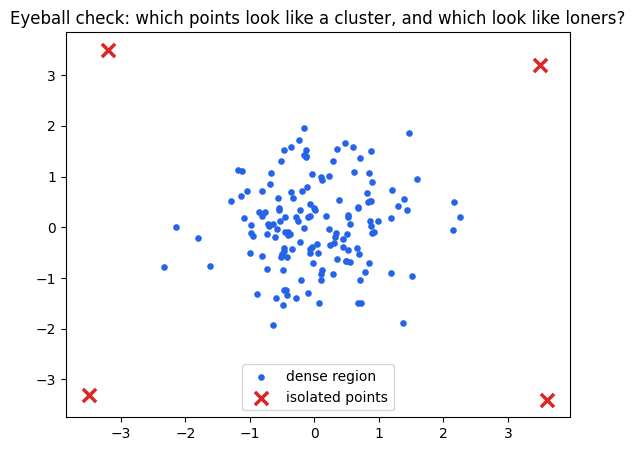

In [4]:
eyeball_rng = np.random.RandomState(3)
dense_region = eyeball_rng.normal(0, 0.8, size=(150, 2))
isolated_points = np.array([[3.5, 3.2], [-3.2, 3.5], [3.6, -3.4], [-3.5, -3.3]])

plt.figure(figsize=(6.5, 5))
plt.scatter(*dense_region.T, s=14, color="#2563EB", label="dense region")
plt.scatter(*isolated_points.T, s=90, color="#DC2626", marker="x", linewidths=2.5, label="isolated points")
plt.title("Eyeball check: which points look like a cluster, and which look like loners?")
plt.legend()
plt.show()

That eyeball intuition — one crowded blob in the middle, four clear loners in the corners — is exactly what
DBSCAN formalizes with two numbers, covered next.


## 3. Two knobs: `eps` and `MinPts`

**`eps` (ε) — neighborhood radius.** For any point, `eps` answers: *"how far should I look around this point to
see who's nearby?"* Picture drawing an invisible circle of radius `eps` around every point. A small `eps` only
counts very close neighbors; a large `eps` counts neighbors far away too.

**`MinPts` — the density threshold.** How many points need to fall inside that `eps`-circle before the
neighborhood counts as "crowded" (dense)? `eps=2` and `MinPts=5` together mean: *"at least 5 points must fall
within a radius of 2 for this to be a dense neighborhood."*


In [5]:
eps, min_pts = 0.6, 5
point = dense_region[0]
neighbors_mask = np.linalg.norm(dense_region - point, axis=1) <= eps
print(f"Point {point.round(2)}: {neighbors_mask.sum()} neighbors within eps={eps} "
      f"-> {'dense (core point)' if neighbors_mask.sum() >= min_pts else 'not dense enough'} (MinPts={min_pts})")

Point [1.43 0.35]: 8 neighbors within eps=0.6 -> dense (core point) (MinPts=5)


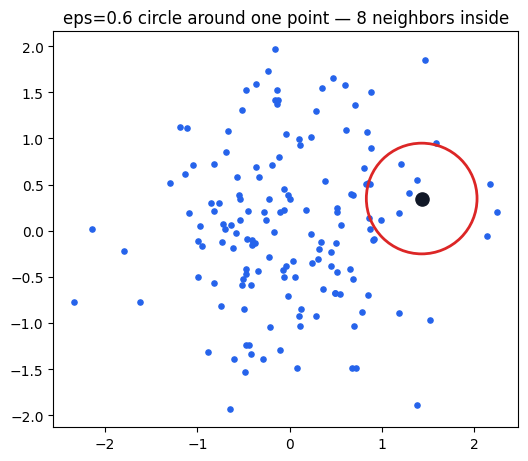

In [6]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(*dense_region.T, s=14, color="#2563EB")
ax.scatter(*point, s=90, color="#111827", zorder=5)
ax.add_patch(Circle(point, eps, fill=False, edgecolor="#DC2626", linewidth=2))
ax.set_title(f"eps={eps} circle around one point — {neighbors_mask.sum()} neighbors inside")
ax.set_aspect("equal")
plt.show()

## 4. Core, border, and noise points

With `eps` and `MinPts` fixed, every point in the dataset falls into exactly one of three buckets:

- **Core point** — its `eps`-neighborhood contains at least `MinPts` points. Sitting comfortably inside a
  crowded region.
- **Border point** — not dense enough on its own, but it falls inside *some core point's* `eps`-neighborhood.
  It's part of a cluster by association, not by its own density.
- **Noise point** — neither core nor border. Genuinely isolated from every dense region.


In [7]:
def point_type(X, i, eps, min_pts):
    dists = np.linalg.norm(X - X[i], axis=1)
    neighbor_idx = np.where((dists <= eps) & (np.arange(len(X)) != i))[0]
    if len(neighbor_idx) + 1 >= min_pts:  # + 1 to count the point itself, matching sklearn's convention
        return "core", neighbor_idx
    # border: not core itself, but check if any core point has it in range
    for j in range(len(X)):
        if j == i:
            continue
        dists_j = np.linalg.norm(X - X[j], axis=1)
        neighbor_idx_j = np.where((dists_j <= eps) & (np.arange(len(X)) != j))[0]
        if len(neighbor_idx_j) + 1 >= min_pts and i in neighbor_idx_j:
            return "border", neighbor_idx
    return "noise", neighbor_idx

demo_rng = np.random.RandomState(11)
core_cluster = demo_rng.normal(0, 0.15, size=(7, 2))    # tightly packed — each point has plenty of close neighbors
border_candidates = np.array([[0.65, 0.05], [-0.15, 0.62]])  # just outside the tight cluster
noise_candidates = np.array([[3.0, 3.0], [-2.8, 2.6]])         # far from everything

X_demo = np.vstack([core_cluster, border_candidates, noise_candidates])
labels_demo = [point_type(X_demo, i, eps=0.6, min_pts=5)[0] for i in range(len(X_demo))]

for kind in ["core", "border", "noise"]:
    print(f"{kind}: {labels_demo.count(kind)} points")

core: 7 points
border: 2 points
noise: 2 points


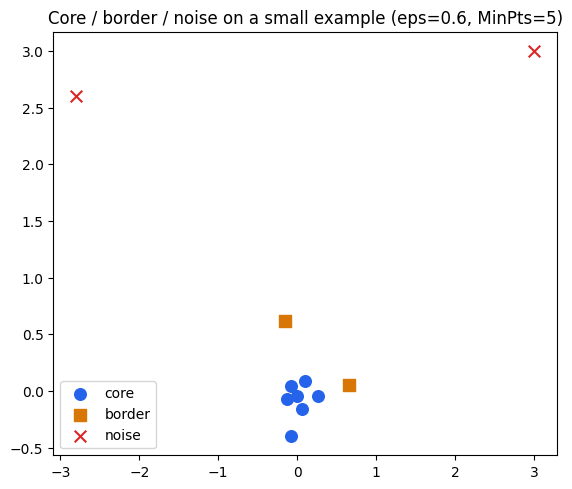

In [8]:
color_map = {"core": "#2563EB", "border": "#D97706", "noise": "#DC2626"}
marker_map = {"core": "o", "border": "s", "noise": "x"}
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for kind in ["core", "border", "noise"]:
    idx = [i for i, k in enumerate(labels_demo) if k == kind]
    if idx:
        ax.scatter(X_demo[idx, 0], X_demo[idx, 1], s=70, color=color_map[kind], marker=marker_map[kind], label=kind)
ax.set_title(f"Core / border / noise on a small example (eps=0.6, MinPts=5)")
ax.legend()
plt.show()

**Quick check**

> A point has only 2 neighbors within its `eps` radius (`MinPts = 5`), but one of those neighbors is a core
> point. What is this point classified as?
>
> **Border point.** It isn't dense enough to be a core point on its own, but it falls inside a core point's
> neighborhood — exactly the definition of a border point.


## 5. The DBSCAN algorithm

```{mermaid}
graph TD
    A["0. Mark every point unvisited"] --> B["1. Pick an unvisited point"]
    B --> C{"Core point?<br/>(>= MinPts neighbors within eps)"}
    C -->|Yes| D["Start a new cluster.<br/>Absorb every point in its neighborhood,<br/>expanding outward through connected core points"]
    C -->|No| E{"Inside some core point's neighborhood?"}
    E -->|Yes| F["Border point — do nothing extra,<br/>already absorbed by that cluster"]
    E -->|No| G["Label as noise"]
    D --> H["Move to next unvisited point"]
    F --> H
    G --> H
    H --> B

    style D fill:#BFDBFE,stroke:#374151,stroke-width:2px,color:#111827
    style G fill:#FCA5A5,stroke:#374151,stroke-width:2px,color:#111827
```

The key mechanism is **density-connectivity**: a cluster isn't just "points near this one core point" — it keeps
expanding through *chains* of core points. If core point A is within `eps` of core point B, and B is within
`eps` of core point C, then A, B, and C (and everything in their neighborhoods) all end up in the same cluster,
even if A and C are far apart. That chaining is exactly what lets DBSCAN trace out a curved, crescent-shaped
cluster instead of only ever drawing blobs.


In [9]:
def dbscan_from_scratch(X, eps, min_pts):
    n = len(X)
    labels = np.full(n, -2)  # -2 = unvisited, -1 = noise, >= 0 = cluster id
    cluster_id = -1

    def region_query(i):
        dists = np.linalg.norm(X - X[i], axis=1)
        return np.where(dists <= eps)[0]  # includes the point itself

    for i in range(n):
        if labels[i] != -2:
            continue
        neighbors = region_query(i)
        if len(neighbors) < min_pts:
            labels[i] = -1  # provisional noise; may still become a border point below
            continue

        cluster_id += 1
        labels[i] = cluster_id
        seeds = list(neighbors)
        seeds.remove(i)
        while seeds:
            j = seeds.pop()
            if labels[j] == -1:
                labels[j] = cluster_id  # was noise, now claimed as a border point
            if labels[j] != -2:
                continue
            labels[j] = cluster_id
            j_neighbors = region_query(j)
            if len(j_neighbors) >= min_pts:
                seeds.extend(n_idx for n_idx in j_neighbors if labels[n_idx] in (-2, -1))
    return labels

scratch_labels = dbscan_from_scratch(X_moons, eps=0.2, min_pts=5)
sklearn_labels = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moons)
print(f"From-scratch clusters found: {len(set(scratch_labels)) - (1 if -1 in scratch_labels else 0)}")
print(f"sklearn clusters found:      {len(set(sklearn_labels)) - (1 if -1 in sklearn_labels else 0)}")
print(f"Labels match sklearn on {100 * (scratch_labels == sklearn_labels).mean():.1f}% of points "
      f"(cluster *numbering* can differ even when the grouping is identical)")

From-scratch clusters found: 2
sklearn clusters found:      2
Labels match sklearn on 100.0% of points (cluster *numbering* can differ even when the grouping is identical)


## 6. Choosing `eps` and `MinPts`

**`MinPts` rule of thumb:** set it to at least `d + 1`, where `d` is the number of features — often `2 x d` in
practice. More features naturally spread points out, so a low, fixed `MinPts` would misread ordinary sparse
regions in high dimensions as noise.

**`eps` — the k-distance elbow method.** For every point, compute the distance to its `k`-th nearest neighbor
(set `k = MinPts`). Sort those distances and plot them. Where the curve suddenly bends upward — the "elbow" — is
where points stop being packed at roughly the same tight spacing and start being genuinely far apart. That
elbow is a data-driven choice for `eps`.


In [10]:
k = 5
neighbors_model = NearestNeighbors(n_neighbors=k).fit(X_moons)
distances, _ = neighbors_model.kneighbors(X_moons)
k_distances = np.sort(distances[:, -1])

print(f"5th-nearest-neighbor distance — 25th/50th/75th percentile: "
      f"{np.percentile(k_distances, 25):.3f} / {np.percentile(k_distances, 50):.3f} / {np.percentile(k_distances, 75):.3f}")

5th-nearest-neighbor distance — 25th/50th/75th percentile: 0.046 / 0.059 / 0.076


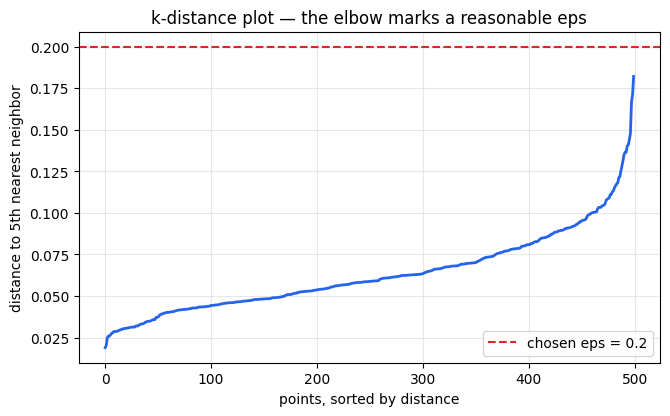

In [11]:
plt.figure(figsize=(7.5, 4.3))
plt.plot(k_distances, color="#2563EB", linewidth=2)
plt.axhline(0.2, color="#DC2626", linestyle="--", label="chosen eps = 0.2")
plt.xlabel("points, sorted by distance"); plt.ylabel(f"distance to {k}th nearest neighbor")
plt.title("k-distance plot — the elbow marks a reasonable eps")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Most points sit at a low, fairly flat distance to their 5th neighbor (the dense crescents), then the curve bends
sharply upward for the last handful of points (points on the sparse edges). `eps = 0.2` sits right at that bend
— which is exactly the value already used above.


## 7. Applied: DBSCAN fixes both of GMM's problems

**Fixing the shape problem** — DBSCAN on the crescent-shaped browsing data:


In [12]:
dbscan_moons = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
moon_labels = dbscan_moons.labels_
print(f"Clusters found: {len(set(moon_labels)) - (1 if -1 in moon_labels else 0)}, "
      f"noise points: {(moon_labels == -1).sum()}")

Clusters found: 2, noise points: 0


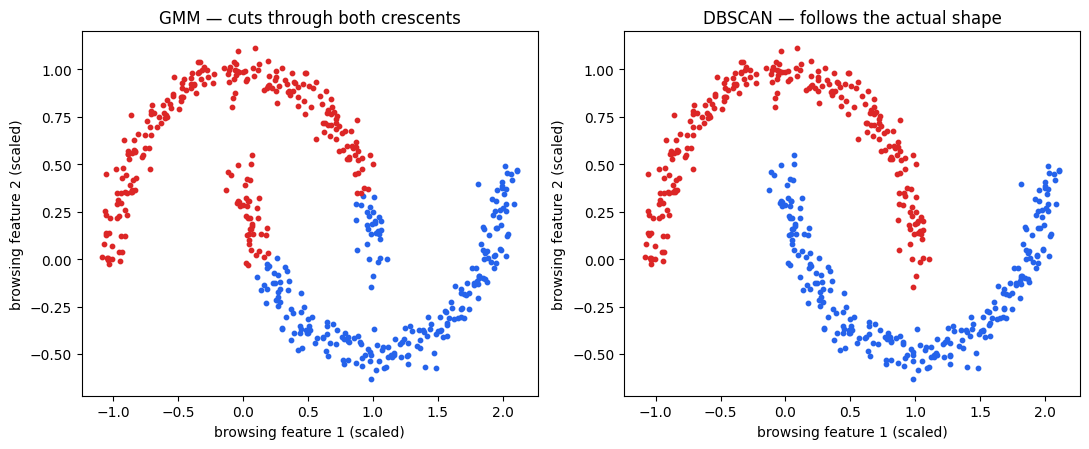

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for j in range(2):
    axes[0].scatter(X_moons[gmm_moon_labels == j, 0], X_moons[gmm_moon_labels == j, 1], s=10, color=colors2[j])
axes[0].set_title("GMM — cuts through both crescents")

for j in sorted(set(moon_labels)):
    color = "#9CA3AF" if j == -1 else colors2[j]
    axes[1].scatter(X_moons[moon_labels == j, 0], X_moons[moon_labels == j, 1], s=10, color=color)
axes[1].set_title("DBSCAN — follows the actual shape")
for ax in axes:
    ax.set_xlabel("browsing feature 1 (scaled)"); ax.set_ylabel("browsing feature 2 (scaled)")
plt.tight_layout()
plt.show()

DBSCAN's density-connectivity chains all the way along each crescent, correctly recovering both curved groups —
something no ellipse-based or centroid-based method can do.

**Fixing the forced-fit problem** — DBSCAN on the customers-plus-resellers dataset from Section 1:


In [14]:
dbscan_customers = DBSCAN(eps=0.9, min_samples=8).fit(X_scaled)
cust_labels = dbscan_customers.labels_
print(f"Clusters found: {len(set(cust_labels)) - (1 if -1 in cust_labels else 0)}, "
      f"noise points flagged: {(cust_labels == -1).sum()} (actual resellers in data: {is_reseller.sum()})")
print(f"Of the {is_reseller.sum()} real reseller accounts, "
      f"{(cust_labels[is_reseller] == -1).sum()} were correctly flagged as noise.")

Clusters found: 2, noise points flagged: 12 (actual resellers in data: 12)
Of the 12 real reseller accounts, 12 were correctly flagged as noise.


Where GMM confidently filed every reseller account into a real customer segment, DBSCAN correctly recognizes
most of them as sitting outside any dense, legitimate-customer neighborhood — flagged as noise instead of forced
into a segment they don't belong to. That's the exact capability Marketing (and Fraud/Risk) needed and neither
GMM nor K-Means could offer.

**Quick check**

> What's the key difference between how GMM and DBSCAN handle a genuinely anomalous data point?
>
> **GMM always assigns it to the highest-likelihood segment anyway; DBSCAN can label it as noise, outside any
> cluster.** Noise isn't a failure mode for DBSCAN — it's a first-class outcome the algorithm is built to produce.


## 8. DBSCAN vs. K-Means vs. Hierarchical vs. GMM

| | K-Means | Hierarchical | GMM | DBSCAN |
|---|---|---|---|---|
| **Cluster shape** | Spherical | Any (via dendrogram cut) | Elliptical | Arbitrary |
| **Handles noise/outliers?** | No — forced assignment | No — forced assignment | No — forced assignment | Yes — explicit noise label |
| **Needs number of clusters upfront?** | Yes (`K`) | Yes (where to cut) | Yes (`K`) | No — clusters emerge from density |
| **Assignment style** | Hard | Hard | Soft (probabilities) | Hard, plus a "not in any cluster" option |

DBSCAN's real edge is native noise detection combined with shape flexibility — exactly what's needed for outlier
detection and fraud flagging, where a point genuinely shouldn't be forced into a "normal" segment.


## 9. Limitations

- **Sensitive to `eps` and `MinPts`.** Get them wrong and DBSCAN either merges everything into one giant cluster
  (`eps` too large) or calls almost everything noise (`eps` too small).
- **Struggles with varying density.** DBSCAN uses one global `eps` for the whole dataset. If Veloura has a tight
  cluster of VIP customers *and* a sparse, spread-out cluster of casual browsers, one `eps` that works for the
  tight cluster will swallow the sparse one into noise, and vice versa.
- **Distance in high dimensions gets less meaningful.** Like every distance-based method, DBSCAN's neighborhoods
  become less informative as the number of features grows very large (the features should usually be scaled
  first, same as GMM and K-Means).


**Hands-on exercise (no code)**

Veloura's Fraud team asks you to run DBSCAN on transaction data, but they set `eps` far larger than the
k-distance elbow suggested, "just to be safe and not miss anything." What's likely to go wrong?

> **Answer:** too large an `eps` makes neighborhoods overlap much more than they should, which tends to merge
> distinct clusters together — including merging the genuine fraud pattern into the legitimate-customer cluster
> it should have been separated from. "Bigger eps to be safe" backfires: it makes DBSCAN *less* able to isolate
> the anomalies, not more.


## 10. Summary — revision cheat sheet

**The big idea:** stop asking "which cluster does this point belong to?" and start asking "is this point in a
crowded neighborhood, or an empty one?" Clusters are dense regions; everything else can be noise.

**Two knobs:**
- `eps` — how far to look around each point.
- `MinPts` — how many neighbors within `eps` counts as "dense."

**Three point types:**
- **Core** — has at least `MinPts` neighbors within `eps`.
- **Border** — not dense on its own, but inside a core point's neighborhood.
- **Noise** — neither. Genuinely isolated.

**The algorithm:** pick an unvisited point, check if it's core, and if so expand a cluster outward through
chains of connected core points (density-connectivity). Anything left over that's not reachable from any core
point is noise.

**Choosing parameters:** `MinPts` >= `d + 1` (often `2 x d`); `eps` from the k-distance elbow plot.

**What DBSCAN fixes that GMM and K-Means can't:** explicit noise detection (no forced assignment for outliers)
and arbitrary cluster shapes (density-connectivity traces curves, not just blobs).

**Limitations:** sensitive to `eps`/`MinPts`, and struggles when real clusters genuinely differ in density from
each other.

**Where this series goes next:** check the [course README](https://github.com/Ujjwal091/ai-ml-course) for the
current module checklist — dimensionality reduction (PCA) is the next unsupervised-learning gap to close.
